# Unseen cultural producers by Seshat home region

In [1]:
import sys

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import statsmodels.api as sm
import statsmodels.formula.api as smf

sys.path.insert(0, '..')
sys.path.insert(0, '../datamodels')
from config import OCCUPATION_MAPPING, ROOT, SESHAT_DB
from datamodel_seshat import UnseenSpecies
from style import *

FIRST_YEAR, LAST_YEAR = -500, 1800
NUM_KNOTS = 10
INTERVAL = 0.95

pd.options.display.float_format = '{:.2f}'.format
apply_style()

## Data

In [2]:
con = duckdb.connect(str(SESHAT_DB), read_only=True)
query = (
    'SELECT DISTINCT wikidata_id, '
    'coalesce(list_filter([d.year FOR d IN death_date], y -> y IS NOT NULL)[1], '
    '         list_filter([d.year FOR d IN birth_date], y -> y IS NOT NULL)[1]) AS year, '
    '[o.label_en FOR o IN occupation] AS occupations, '
    'number_of_works, s.macro_region, s.home_seshat_region '
    'FROM individual, unnest(seshat_polity) AS u(s) '
    'WHERE is_artist OR is_scientist'
)
df = con.execute(query).df()
con.close()

print(len(df), 'rows |', df['wikidata_id'].nunique(), 'individuals')
df

1111498 rows | 1111405 individuals


,wikidata_id,year,occupations,number_of_works,macro_region,home_seshat_region
0,Q108658654,1940,"[teacher, poet, literary scholar]",0,Southwest Asia,Anatolia-Caucasus
1,Q108659541,1987,"[textile artist, university teacher]",0,East Asia,Northeast Asia
2,Q108662896,1904,[writer],0,Europe,Western Europe
3,Q110398789,1836,"[composer, organist]",0,Europe,Southern Europe
4,Q124034282,1978,[artist],0,Europe,Northern Europe
...,...,...,...,...,...,...
1111493,Q95391175,1951,[secondary school teacher],0,Europe,Central Europe
1111494,Q95391364,1949,[secondary school teacher],0,Europe,Central Europe
1111495,Q95322848,1842,"[pastor, philosopher]",0,Europe,Western Europe
1111496,Q95323808,1957,"[singer, playwright, actor, author]",0,Europe,Central Europe


In [3]:
mapping = pd.read_csv(OCCUPATION_MAPPING)
OCCUPATIONS = dict(zip(mapping['wikidata_occupation'], mapping['occupation']))
mapping

,wikidata_occupation,occupation
0,painter,Painter
1,poet,Writer
2,composer,Musician
3,historian,Writer
4,theologian,Writer
5,architect,Architect
6,sculptor,Sculptor
7,translator,Writer
8,botanist,Writer
9,philosopher,Writer


In [4]:
df = df[(df['year'] >= FIRST_YEAR) & (df['year'] < LAST_YEAR)]

occupations = df[['wikidata_id', 'occupations']].drop_duplicates('wikidata_id').explode('occupations')
occupations['occupation'] = occupations['occupations'].map(OCCUPATIONS)
occupations = occupations.dropna(subset='occupation')[['wikidata_id', 'occupation']].drop_duplicates().sort_values(['wikidata_id', 'occupation'])
occupations = occupations.sample(frac=1, random_state=42).drop_duplicates('wikidata_id')
print(df['wikidata_id'].nunique() - len(occupations), 'individuals without a mapped occupation, left out')
df = df.drop(columns='occupations').merge(occupations, on='wikidata_id')
df['decade'] = (df['year'] / 10).round() * 10


def works_category(number_of_works):
    if number_of_works <= 1:
        return 'f1'
    if number_of_works == 2:
        return 'f2'
    return 'f>2'


df['works'] = pd.Categorical(df['number_of_works'].map(works_category), categories=['f1', 'f2', 'f>2'])

counts = df.pivot_table(index=['macro_region', 'home_seshat_region'], columns='works', values='wikidata_id', aggfunc='count', observed=False).reset_index()
kept = counts[counts['f2'] > 0]['home_seshat_region']
print(len(df), 'rows |', df['wikidata_id'].nunique(), 'individuals from', FIRST_YEAR, 'to', LAST_YEAR, '|', counts.shape[0], 'home regions,',
      len(kept), 'with at least one doubleton')
print('left out, no doubleton:', ', '.join(counts[counts['f2'] == 0]['home_seshat_region']))
df = df[df['home_seshat_region'].isin(kept)]
df['works'].value_counts()

15600 individuals without a mapped occupation, left out
34739 rows | 34679 individuals from -500 to 1800 | 34 home regions, 24 with at least one doubleton
left out, no doubleton: East Africa, West Africa, Pontic-Caspian, Siberia, Tibet, Mexico, Andes, Pakistan, Sri Lanka, Mainland Southeast Asia


works
f1     29346
f>2     3981
f2      1384
Name: count, dtype: int64

## Model

In [5]:
sample = df[df['works'] != 'f>2'].copy()
sample['y'] = (sample['works'] == 'f2').astype(int)

knots = np.linspace(sample['decade'].min(), sample['decade'].max(), NUM_KNOTS)[1:-1]
model = smf.glm('y ~ bs(decade, knots=knots) + C(occupation) + C(home_seshat_region)', data=sample, family=sm.families.Binomial()).fit()

coefficients = pd.DataFrame({'coefficient': model.params, 'p_value': model.pvalues})
coefficients[~coefficients.index.str.startswith('bs(')]

,coefficient,p_value
Intercept,-1.64,0.19
C(occupation)[T.Musician],-1.41,0.00
C(occupation)[T.Painter],0.11,0.70
C(occupation)[T.Performing Artist],-0.34,0.27
C(occupation)[T.Sculptor],0.18,0.60
C(occupation)[T.Writer],-0.86,0.00
C(home_seshat_region)[T.Anatolia-Caucasus],-0.16,0.84
C(home_seshat_region)[T.Arabia],-0.26,0.79
C(home_seshat_region)[T.Central Europe],-0.86,0.26
C(home_seshat_region)[T.East Coast],-0.87,0.49


## Unseen individuals

In [6]:
prediction = model.get_prediction(sample).summary_frame(alpha=1 - INTERVAL)


def unseen(p):
    l = 2 * p / (1 - p)
    return 1 / (l + l ** 2 / 2)


sample['f0'] = unseen(prediction['mean'].values)
sample['f0_max'] = unseen(prediction['mean_ci_lower'].values)
sample['f0_min'] = unseen(prediction['mean_ci_upper'].values)

estimates = (
    sample.groupby(['macro_region', 'home_seshat_region'])[['f0_min', 'f0', 'f0_max']].sum()
    .join(counts.set_index(['macro_region', 'home_seshat_region']))
    .reset_index()
)
observed = estimates['f1'] + estimates['f2']
for suffix in ('', '_min', '_max'):
    estimates['estimated' + suffix] = observed + estimates['f0' + suffix]
estimates['survival_ratio'] = observed / estimates['estimated']
estimates['survival_ratio_min'] = observed / estimates['estimated_max']
estimates['survival_ratio_max'] = observed / estimates['estimated_min']
estimates = estimates.sort_values('survival_ratio')
estimates[['macro_region', 'home_seshat_region', 'f1', 'f2', 'f>2', 'f0', 'estimated', 'survival_ratio_min', 'survival_ratio', 'survival_ratio_max']]

,macro_region,home_seshat_region,f1,f2,f>2,f0,estimated,survival_ratio_min,survival_ratio,survival_ratio_max
9,Europe,Central Europe,9109,210,594,229935.48,239254.48,0.03,0.04,0.05
10,Europe,Eastern Europe,261,7,29,5551.49,5819.49,0.02,0.05,0.10
15,North America,East Coast,40,1,5,849.11,890.11,0.01,0.05,0.29
11,Europe,Northern Europe,1373,46,107,23339.89,24758.89,0.04,0.06,0.08
22,Southwest Asia,Levant,89,3,26,1374.07,1466.07,0.02,0.06,0.19
13,Europe,Southern Europe,6541,320,853,85399.43,92260.43,0.06,0.07,0.09
6,East Asia,North China,1825,105,546,18902.83,20832.83,0.07,0.09,0.12
21,Southwest Asia,Iran,427,25,80,4421.46,4873.46,0.06,0.09,0.15
14,Europe,Western Europe,7041,425,1194,68986.55,76452.55,0.08,0.10,0.11
19,Southwest Asia,Anatolia-Caucasus,939,72,126,8721.14,9732.14,0.08,0.10,0.14


## Save

In [7]:
UNSEEN = ROOT / 'data/processed/unseen_species.csv'

sample['century'] = (sample['year'] // 100) * 100
df['century'] = (df['year'] // 100) * 100
observed = df.pivot_table(index=['home_seshat_region', 'century'], columns='works', values='wikidata_id', aggfunc='nunique', observed=False, fill_value=0)
unseen_species = (
    sample.groupby(['home_seshat_region', 'century'])[['f0', 'f0_min', 'f0_max']].sum()
    .join(observed, how='outer')
    .fillna(0)
    .reset_index()
    .astype({'f1': int, 'f2': int, 'f>2': int})
    [[field.alias or name for name, field in UnseenSpecies.model_fields.items()]]
)
for row in unseen_species.to_dict('records'):
    UnseenSpecies.model_validate(row)
unseen_species.to_csv(UNSEEN, index=False)
print(len(unseen_species), 'rows saved to', UNSEEN.name)
unseen_species

273 rows saved to unseen_species.csv


,home_seshat_region,century,f0,f0_min,f0_max,f1,f2,f>2
0,Afghanistan,1000,38.06,6.49,180.21,8,2,8
1,Afghanistan,1100,13.06,2.16,62.34,4,0,1
2,Afghanistan,1200,7.42,1.23,35.70,2,0,1
3,Afghanistan,1700,31.52,5.99,145.42,4,0,0
4,Anatolia-Caucasus,-500,20.15,2.26,139.63,3,0,0
...,...,...,...,...,...,...,...,...
268,Western Europe,1300,786.76,615.09,1003.72,158,16,47
269,Western Europe,1400,1155.69,924.65,1442.74,175,22,83
270,Western Europe,1500,5849.84,4837.37,7077.85,682,45,128
271,Western Europe,1600,24251.35,20520.23,28705.99,2203,90,288


## Survival ratio by home region

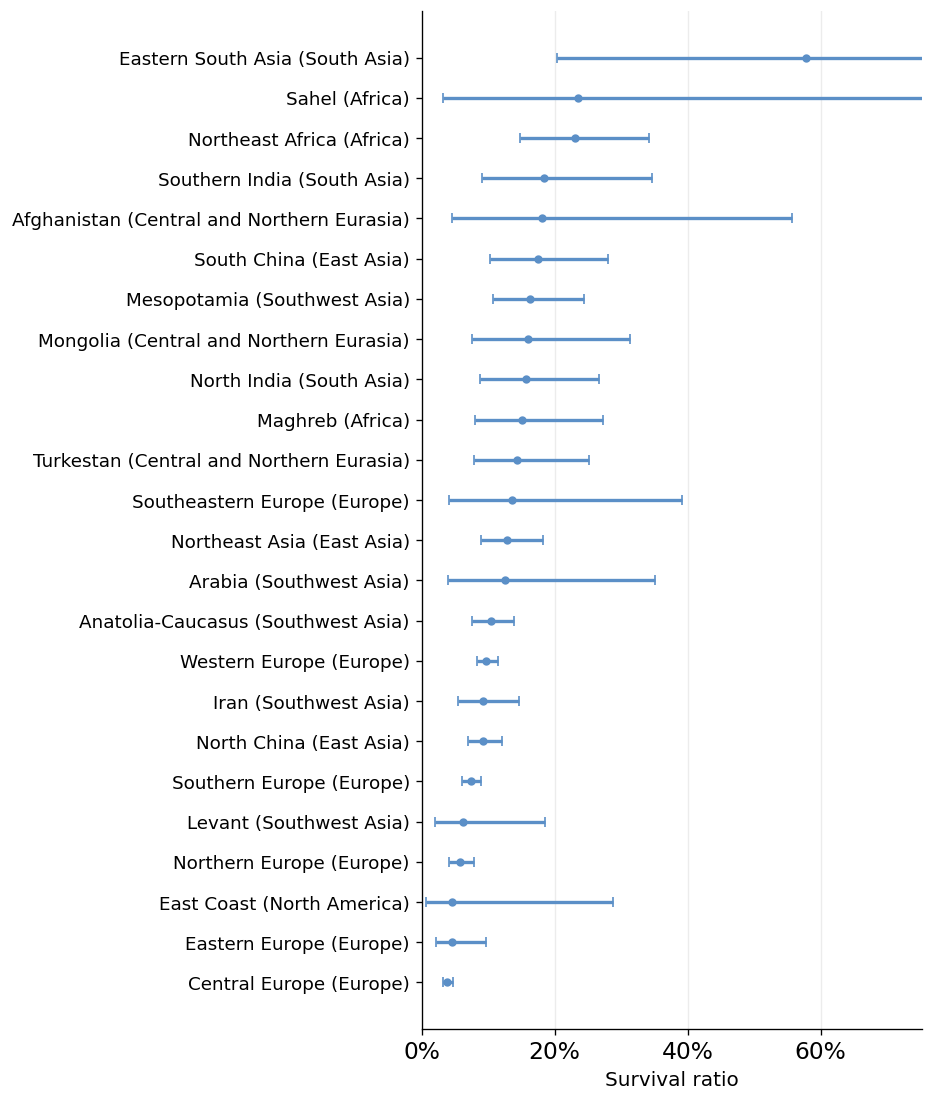

In [8]:
fig, ax = plt.subplots(figsize=(8, 0.35 * len(estimates) + 1))
y = np.arange(len(estimates))
ratio = estimates['survival_ratio'] * 100
errors = [ratio - estimates['survival_ratio_min'] * 100, estimates['survival_ratio_max'] * 100 - ratio]
ax.errorbar(ratio, y, xerr=errors, fmt='o', color=MAIN_COLOR, ecolor=MAIN_COLOR, capsize=3, markersize=4)
ax.set_yticks(y, estimates['home_seshat_region'] + ' (' + estimates['macro_region'] + ')', fontsize=11)
ax.xaxis.set_major_formatter(ticker.PercentFormatter(100, decimals=0))
ax.set_xlim(0, ratio.max() * 1.3)
ax.set_xlabel('Survival ratio', fontsize=12)
ax.grid(axis='x', color=GRID_COLOR)
fig.tight_layout()
plt.show()

## Observed and estimated by century

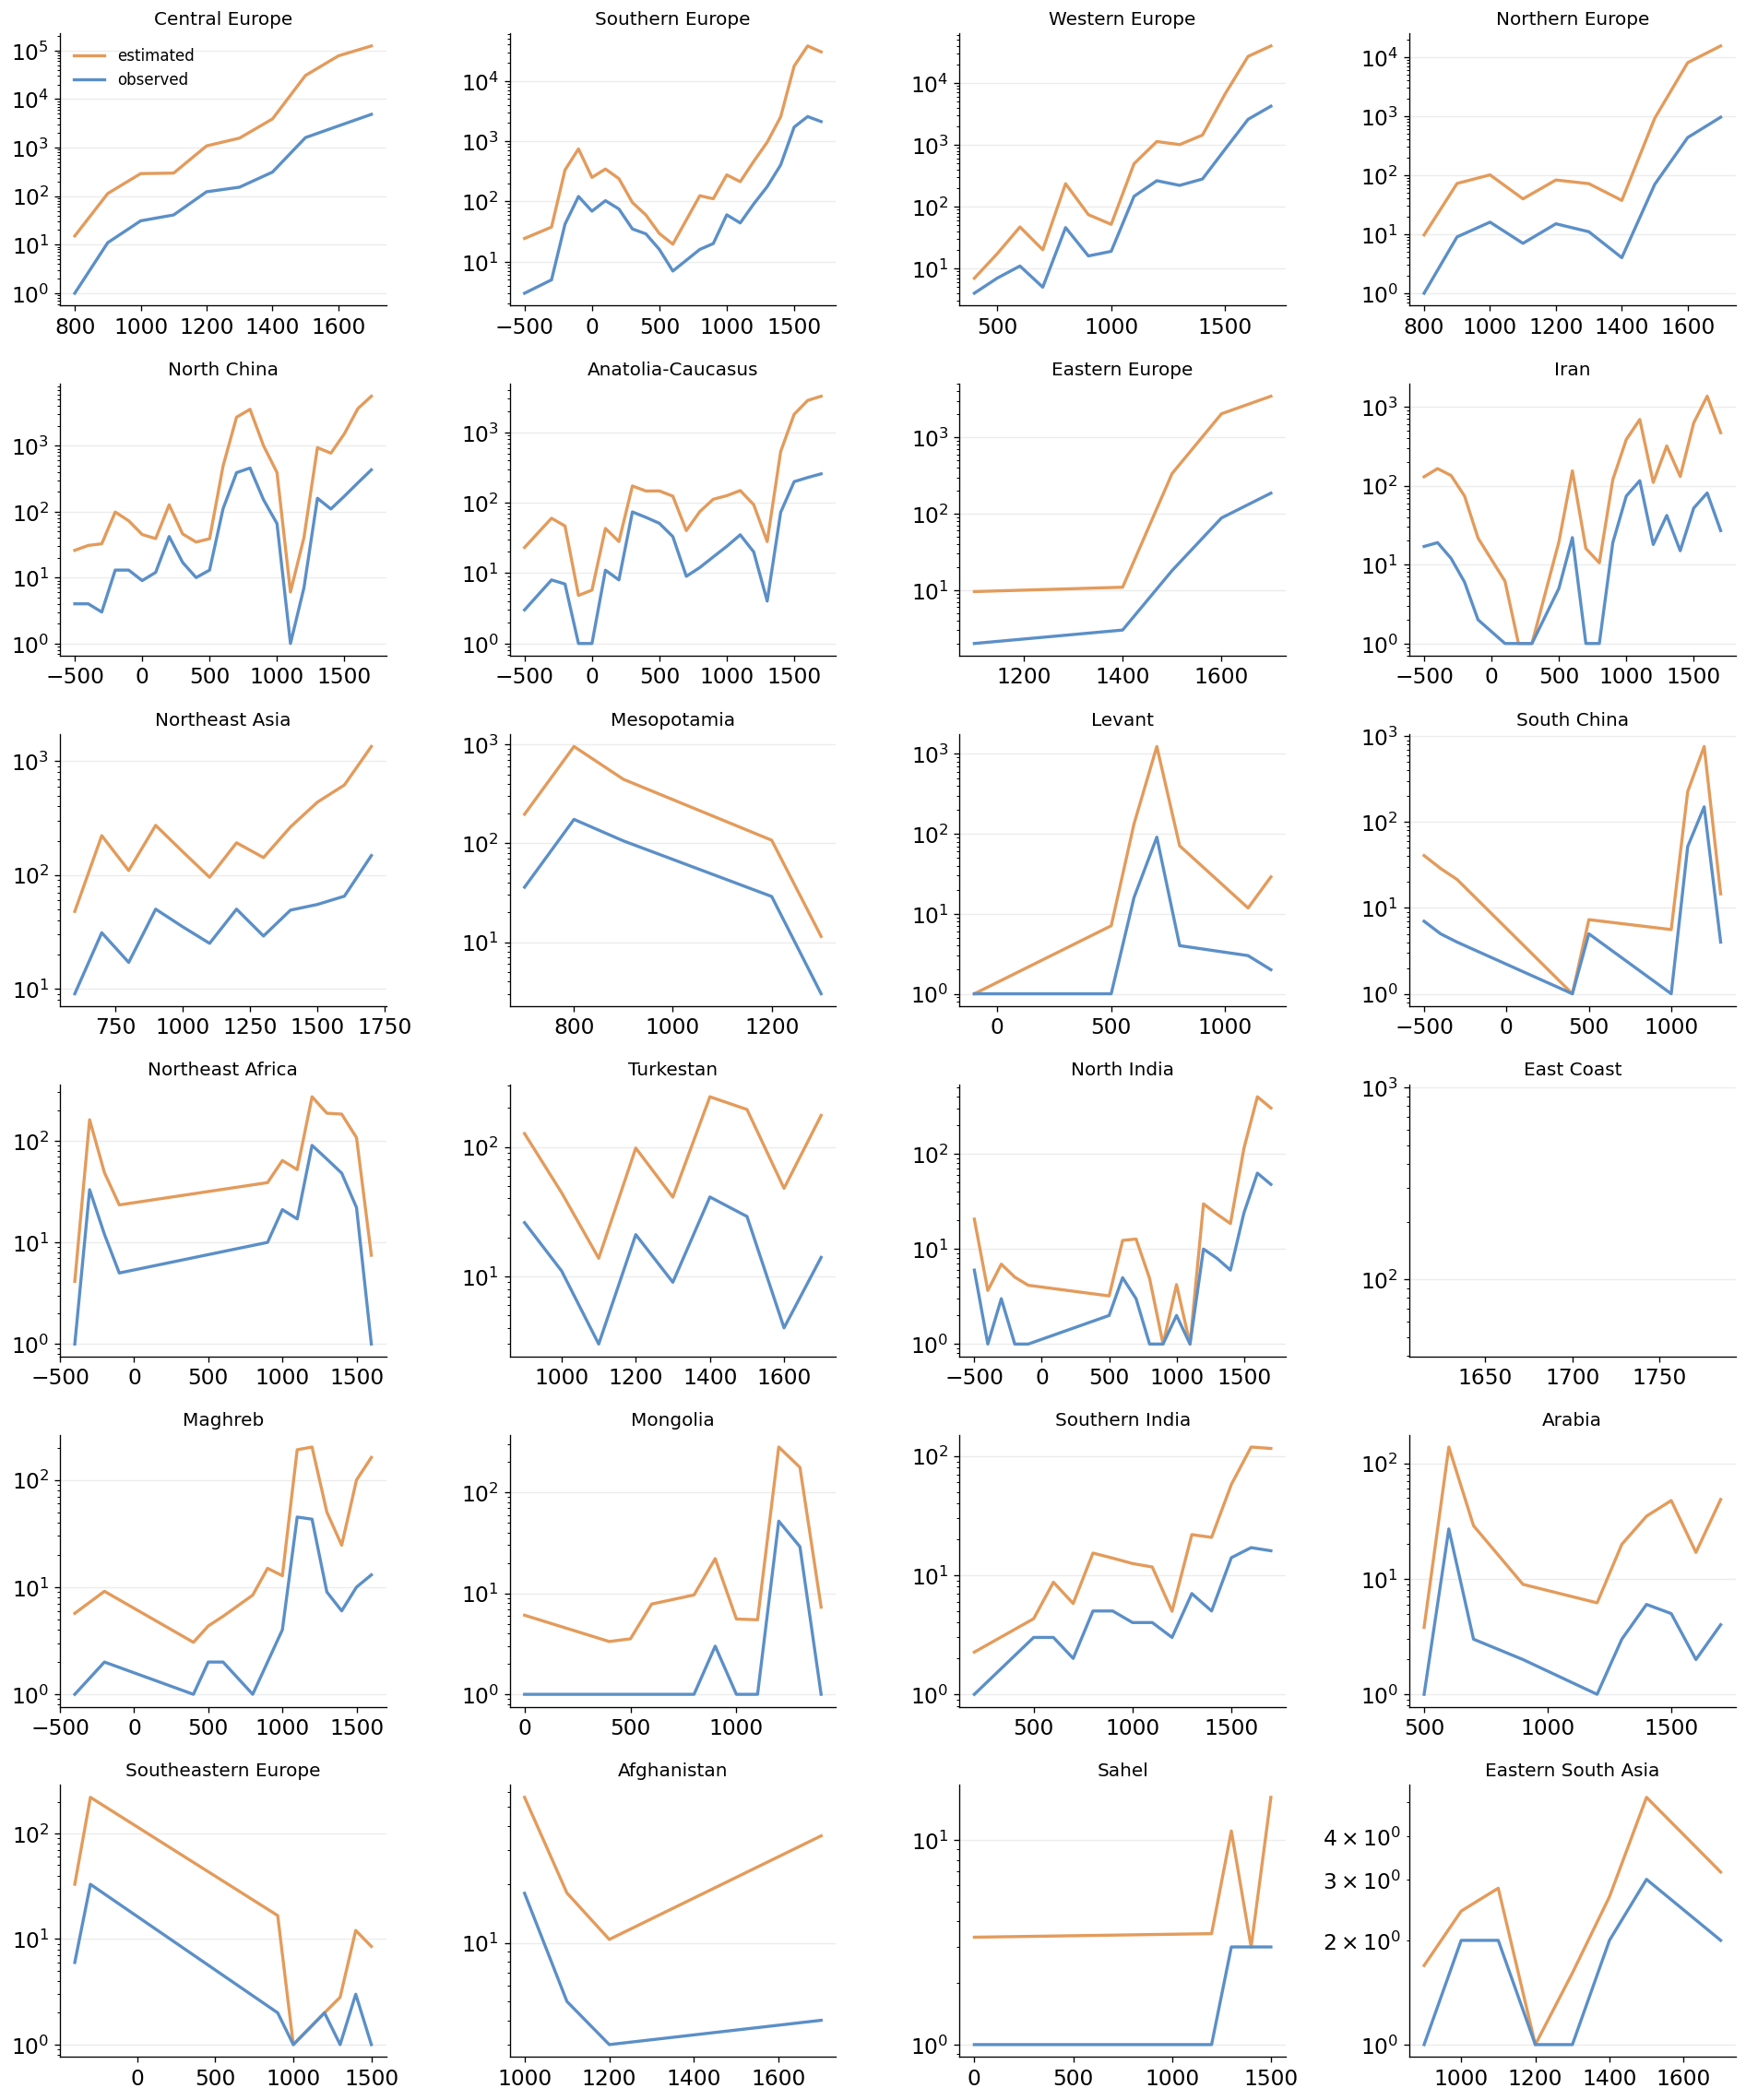

In [9]:
df['century'] = (df['year'] // 100) * 100
by_century = (
    df.groupby(['home_seshat_region', 'century']).size().rename('observed').to_frame()
    .join(sample.groupby(['home_seshat_region', 'century'])['f0'].sum())
    .fillna(0)
    .reset_index()
)
by_century['estimated'] = by_century['observed'] + by_century['f0']

regions = estimates.sort_values('estimated', ascending=False)['home_seshat_region']
columns = 4
rows = -(-len(regions) // columns)
fig, axes = plt.subplots(rows, columns, figsize=(16, 3.2 * rows), squeeze=False)
for ax, region in zip(axes.flat, regions):
    r = by_century[by_century['home_seshat_region'] == region]
    ax.plot(r['century'], r['estimated'], color=ORANGE, linewidth=2, label='estimated')
    ax.plot(r['century'], r['observed'], color=MAIN_COLOR, linewidth=2, label='observed')
    ax.set_yscale('log')
    ax.set_title(region, fontsize=12)
    ax.grid(axis='y', color=GRID_COLOR)
for ax in axes.flat[len(regions):]:
    ax.axis('off')
axes[0, 0].legend(fontsize=10)
fig.tight_layout()
plt.show()